In [4]:
import polars as pl
from plotnine import aes, geom_point, geom_line, ggplot, labs, theme_minimal

trips = pl.read_csv("../Data/Laboration 1/trips.txt")
stop_times = pl.read_csv("../Data/Laboration 1/stop_times.txt")
final_trip_updates = pl.read_parquet("../Data/Laboration 1/final_trip_updates.parquet")

trips.head(), stop_times.head(), final_trip_updates.head()

(shape: (5, 8)
 ┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
 │ route_id   ┆ service_id ┆ trip_id    ┆ trip_head ┆ trip_shor ┆ direction ┆ shape_id  ┆ samtrafik │
 │ ---        ┆ ---        ┆ ---        ┆ sign      ┆ t_name    ┆ _id       ┆ ---       ┆ en_intern │
 │ i64        ┆ i64        ┆ i64        ┆ ---       ┆ ---       ┆ ---       ┆ i64       ┆ al_trip_n │
 │            ┆            ┆            ┆ str       ┆ str       ┆ i64       ┆           ┆ umb…      │
 │            ┆            ┆            ┆           ┆           ┆           ┆           ┆ ---       │
 │            ┆            ┆            ┆           ┆           ┆           ┆           ┆ i64       │
 ╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
 │ 9011005000 ┆ 3          ┆ 5570000007 ┆ null      ┆ null      ┆ 1         ┆ 205570000 ┆ 175       │
 │ 200000     ┆            ┆ 8906808    ┆           ┆           ┆  

In [5]:
trip_stop_sequences = (
    trips.select(["trip_id", "route_id"])
    .join(stop_times.select(["trip_id", "stop_sequence", "stop_id"]), on="trip_id", how="inner")
    .group_by(["route_id", "trip_id"])
    .agg(pl.col("stop_id").sort_by("stop_sequence").alias("stop_sequence"))
)

route_stop_sequence_summary = (
    trip_stop_sequences
    .group_by(["route_id", "stop_sequence"])
    .agg(pl.len().alias("n_trips"))
    .sort(["n_trips"], descending=[True])
)

route_stop_sequence_summary.head()

route_id,stop_sequence,n_trips
i64,list[i64],u32
9011005000200000,"[9022005000023017, 9022005000022017, … 9022005000007017]",99
9011005000300000,"[9022005000010017, 9022005001034017, … 9022005000012017]",99
9011005000200000,"[9022005000007016, 9022005001006016, … 9022005000023018]",98
9011005000300000,"[9022005000012016, 9022005001039016, … 9022005000010016]",98
9011005020300000,"[9022005000219001, 9022005001339001, … 9022005000050005]",87


In [6]:
route_id_input = 9011005020200000
stop_sequence_input = (
    route_stop_sequence_summary
    .filter(pl.col("route_id") == route_id_input)
    .sort("n_trips", descending=True)
    .select("stop_sequence")
    .to_series()
    .first()
)
min_stop = 9
max_stop = 100

matching_trips = (
    trip_stop_sequences
    .filter(
        (pl.col("route_id") == route_id_input)
        & (pl.col("stop_sequence") == stop_sequence_input)
    )
    .select(pl.col("trip_id").cast(pl.Utf8).alias("trip_id"))
)

if "current_stop_sequence" in final_trip_updates.columns:
    current_stop_col = "current_stop_sequence"
elif "stop_sequence" in final_trip_updates.columns:
    current_stop_col = "stop_sequence"
else:
    raise ValueError("No current stop-sequence column found in final_trip_updates.")

trip_delay_table = (
    final_trip_updates
    .with_columns(pl.col("trip_id").cast(pl.Utf8).alias("trip_id"))
    .join(matching_trips, on="trip_id", how="inner")
    .filter(pl.col(current_stop_col) >= min_stop)
    .filter(pl.col(current_stop_col) <= max_stop)
    .select([
        "trip_id",
        pl.col(current_stop_col).cast(pl.Int64, strict=False).alias("current_stop_sequence"),
        pl.col("arrival_delay").cast(pl.Float64, strict=False).alias("arrival_delay"),
    ])
    .drop_nulls(["current_stop_sequence", "arrival_delay"])
    .sort(["trip_id", "current_stop_sequence"])
)

trip_delay_table[["current_stop_sequence","arrival_delay"]]


current_stop_sequence,arrival_delay
i64,f64
9,81.0
10,-6.0
11,-84.0
12,-137.0
13,-188.0
…,…
9,48.0
10,-30.0
11,-94.0


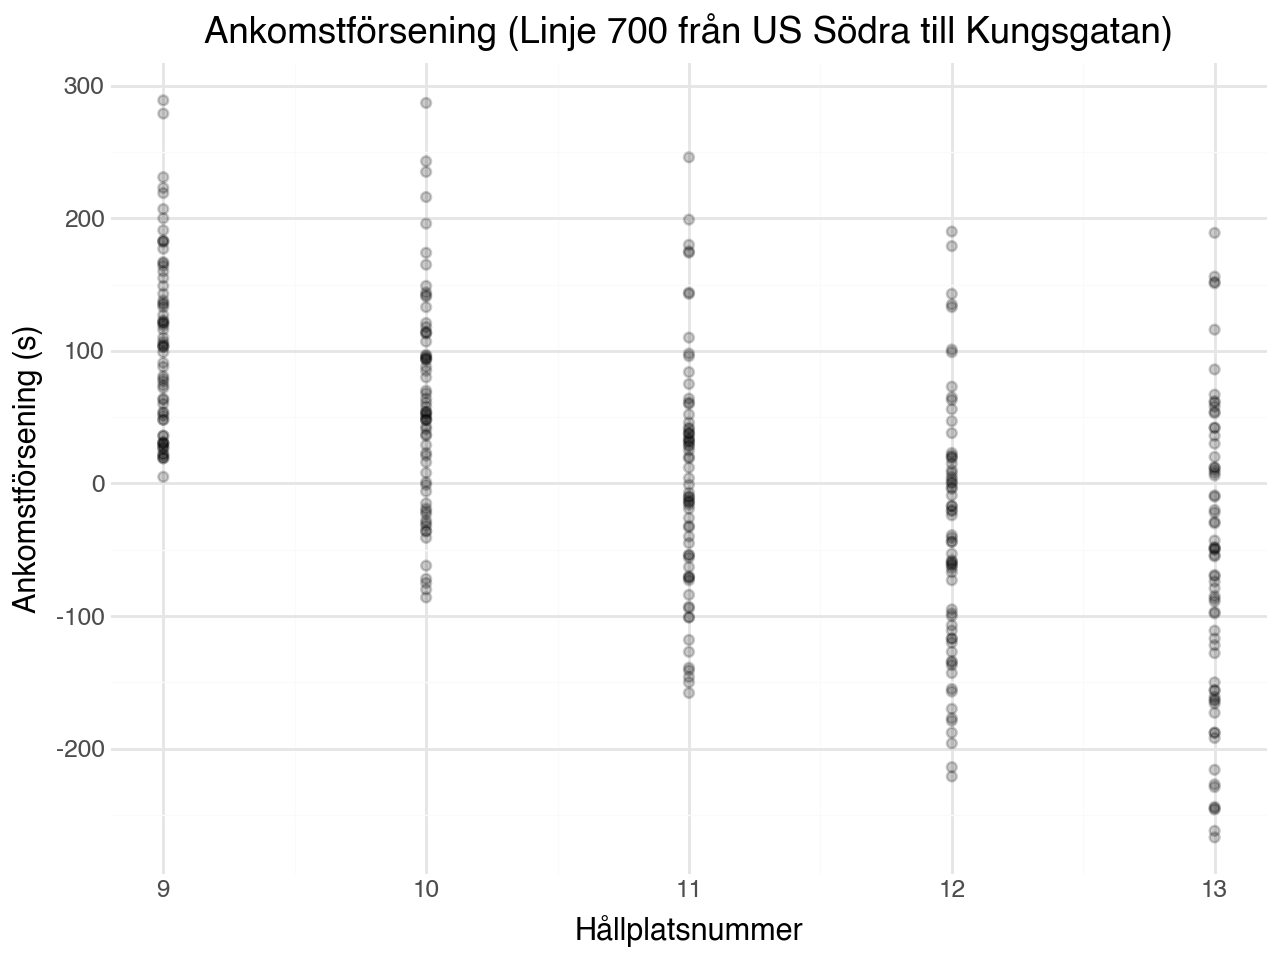

In [7]:

trip_delay_plot = (
    ggplot(
        trip_delay_table.to_pandas(),
        aes(x="current_stop_sequence", y="arrival_delay"),
    )
    + geom_point(alpha=0.2)
    + labs(
        x="Hållplatsnummer",
        y="Ankomstförsening (s)",
        title=f"Ankomstförsening (Linje 700 från US Södra till Kungsgatan)",
    )
    + theme_minimal()
)

trip_delay_plot

In [8]:
print(route_id_input)
print(stop_sequence_input)


9011005020200000
[9022005000469002, 9022005004084001, 9022005004076001, 9022005004250001, 9022005004251001, 9022005004236002, 9022005004230002, 9022005001249002, 9022005000198002, 9022005000042002, 9022005000046004, 9022005001243002, 9022005000050006]


                     Results: Ordinary least squares
Model:                 OLS                Adj. R-squared:       0.314    
Dependent Variable:    arrival_delay      AIC:                  3972.6143
Date:                  2026-04-30 13:23   BIC:                  3980.2425
No. Observations:      335                Log-Likelihood:       -1984.3  
Df Model:              1                  F-statistic:          153.9    
Df Residuals:          333                Prob (F-statistic):   2.57e-29 
R-squared:             0.316              Scale:                8223.2   
-------------------------------------------------------------------------
                       Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
-------------------------------------------------------------------------
Intercept             492.4701  38.8541  12.6749 0.0000 416.0397 568.9006
current_stop_sequence -43.4672   3.5034 -12.4073 0.0000 -50.3587 -36.5757
-----------------------------------------------------------

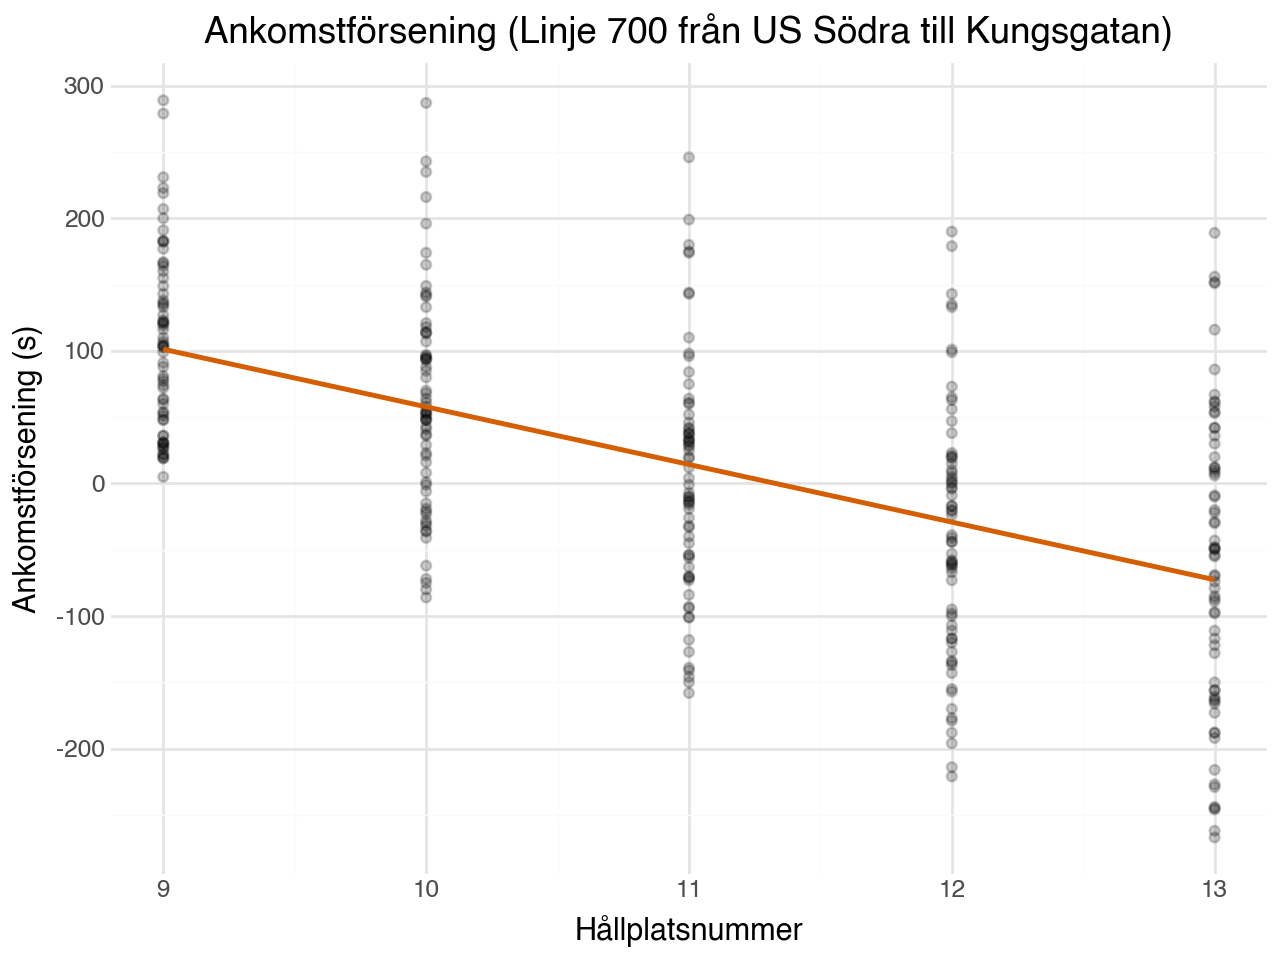

In [9]:
import statsmodels.formula.api as smf
from plotnine import geom_line

trip_delay = trip_delay_table.to_pandas().copy()

model = smf.ols("arrival_delay ~ current_stop_sequence", trip_delay)
model = model.fit()
print(model.summary2())

trip_delay["predicted_arrival_delay"] = model.predict(trip_delay)
trip_delay_pd = trip_delay.sort_values("current_stop_sequence")

trip_delay_model_plot = (
    ggplot(trip_delay, aes(x="current_stop_sequence", y="arrival_delay"))
    + geom_point(alpha=0.2)
    + geom_line(aes(y="predicted_arrival_delay"), color="#D55E00", size=1.0)
    + labs(
        x="Hållplatsnummer",
        y="Ankomstförsening (s)",
        title=f"Ankomstförsening (Linje 700 från US Södra till Kungsgatan)",
    )
    + theme_minimal()
)

trip_delay_model_plot

In [ ]:
#Read reason codes
reasons = pl.read_parquet("../Data/Laboration 3/reasons.parquet")
reasons.head()

FileNotFoundError: No such file or directory (os error 2): Data/Laboration 3/reasons.parquet